In [1]:
from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.utils import FRED
from SymbolicDSGE.utils.math_utils import HP_two_sided, annualized_log_percent, detrend
from SymbolicDSGE.bayesian import make_prior
from SymbolicDSGE.regression import (
    SymbolicRegressor,
    TemplateConfig,
    PySRParams,
    ModelParametrizer,
)

from sympy import Matrix, Float, preorder_traversal
from warnings import catch_warnings, simplefilter

from numpy import array, float64, ceil, sqrt, log, std, random, isclose
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import cProfile

_FIGSIZE_1D = (10, 6)
_FIGSIZE_2D = (12, 6)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
model, kalman = ModelParser("../MODELS/POST82.yaml").get_all()

with catch_warnings():
    # Equations in a sp.Matrix are deprecated, this is only used as a pretty print function
    simplefilter(action="ignore")
    mat = Matrix(model.equations.model)
mat

Matrix([
[                                    Eq(Pi(t), beta*Pi(t + 1) + kappa*(x(t) - z(t)))],
[                           Eq(x(t), -tau_inv*(-Pi(t + 1) + r(t)) + g(t) + x(t + 1))],
[Eq(r(t), e_r + rho_r*r(t - 1*1) + (1 - rho_r)*(psi_pi*Pi(t) + psi_x*(x(t) - z(t))))],
[                                                   Eq(g(t), e_g + rho_g*g(t - 1*1))],
[                                                   Eq(z(t), e_z + rho_z*z(t - 1*1))]])

In [3]:
fred = FRED(
    key_env=None,  # None => look for the ".env" file. If you have a custom env file, provide its path here.
    key_name="FRED_KEY",  # Name of the variable in the env file that contains the FRED API key.
)
df = fred.get_frame(
    series_ids=[
        "A939RX0Q048SBEA",  # Real GDP per Cap.
        "CPIAUCSL",  # Consumer Price Index for All Urban Consumers: All Items
        "FEDFUNDS",  # Effective Federal Funds Rate
    ],
    date_range=(
        "1955-01-01",
        "2007-10-01",
    ),  # Date range for the data ("YYYY-MM-DD" format or a pd.DatetimeIndex object)
)

gdp_q = df["A939RX0Q048SBEA"]  # already quarterly in most pulls; verify freq

cpi_q = df["CPIAUCSL"].resample("QS").mean()  # quarterly avg CPI
ffr_q = df["FEDFUNDS"].resample("QS").mean()  # quarterly avg policy rate

idx_range = pd.date_range(start="1984-01-01", end="2007-01-01", freq="QS")


df = pd.DataFrame(
    {
        "A939RX0Q048SBEA": gdp_q.reindex(idx_range),
        "CPIAUCSL": cpi_q.reindex(idx_range),
        "FEDFUNDS": ffr_q.reindex(idx_range),
    }
)

df

,A939RX0Q048SBEA,CPIAUCSL,FEDFUNDS
1984-01-01,34103.0,102.533333,9.686667
1984-04-01,34622.0,103.500000,10.556667
1984-07-01,34871.0,104.400000,11.390000
1984-10-01,35072.0,105.300000,9.266667
1985-01-01,35346.0,106.266667,8.476667
...,...,...,...
2006-01-01,54927.0,199.466667,4.456667
2006-04-01,54945.0,201.266667,4.906667
2006-07-01,54886.0,203.166667,5.246667
2006-10-01,55216.0,202.333333,5.246667


In [4]:
x_trend = HP_two_sided(log(df["A939RX0Q048SBEA"]), lamb=1600)[
    0
]  # returns (trend, cycle)
x = (
    log(df["A939RX0Q048SBEA"]) - x_trend
) * 100  # HP detrended quarterly log output gap


inf_lvl = annualized_log_percent(df["CPIAUCSL"], periods_per_year=4)
rate_lvl = df["FEDFUNDS"]

r_ss = model.calibration.parameters["r_star"]
pi_ss = model.calibration.parameters["pi_star"]

rate = (rate_lvl - (r_ss + pi_ss)) / 4  # gap to steady state
inf = (inf_lvl - pi_ss) / 4  # gap to steady state

df_model_units = pd.DataFrame(
    {
        "r": rate,
        "Pi": inf,
        "x": x,
    }
).dropna()

observed = pd.DataFrame(
    {
        "OutGap": df_model_units["x"],
        "Infl": inf_lvl[df_model_units.index],
        "Rate": rate_lvl[df_model_units.index],
    }
)
observed.index = df_model_units.index

In [6]:
prior_spec = {
    # (0, 1)
    "beta": make_prior(
        "beta",
        parameters={"a": 100 * 0.99, "b": 100 * 0.001},
        transform="logit",
    ),
    "rho_r": make_prior(
        "beta",
        parameters={"a": 100 * 0.84, "b": 100 * 0.16},
        transform="logit",
    ),
    "rho_g": make_prior(
        "beta",
        parameters={"a": 100 * 0.83, "b": 100 * 0.17},
        transform="logit",
    ),
    "rho_z": make_prior(
        "beta",
        parameters={"a": 100 * 0.85, "b": 100 * 0.15},
        transform="logit",
    ),
    # (0, +inf)
    "psi_pi": make_prior(
        "gamma",
        parameters={"mean": 2.19, "std": 0.5},
        transform="log",
    ),
    "psi_x": make_prior(
        "gamma",
        parameters={"mean": 0.30, "std": 0.1},
        transform="log",
    ),
    "kappa": make_prior(
        "gamma",
        parameters={"mean": 0.58, "std": 0.1},
        transform="log",
    ),
    "tau_inv": make_prior(
        "gamma",
        parameters={"mean": 1.86, "std": 0.5},
        transform="log",
    ),
    # Correlation (-1,1)
    "rho_gz": make_prior(
        "trunc_normal",
        parameters={"mean": 0.0, "std": 0.20, "low": -1.0, "high": 1.0},
        transform="affine_logit",
        transform_kwargs={
            "low": -1.0,
            "high": 1.0,
        },
    ),
    # Shock std devs (0, +inf)
    "sig_r": make_prior(
        "gamma",
        parameters={"mean": 0.18, "std": 0.1},
        transform="log",
    ),
    "sig_g": make_prior(
        "gamma",
        parameters={"mean": 0.18, "std": 0.1},
        transform="log",
    ),
    "sig_z": make_prior(
        "gamma",
        parameters={"mean": 0.64, "std": 0.1},
        transform="log",
    ),
    "meas_outgap": make_prior(
        "gamma",
        parameters={"mean": 0.5, "std": 0.1},
        transform="log",
    ),
    "meas_infl": make_prior(
        "gamma",
        parameters={"mean": 0.5, "std": 0.1},
        transform="log",
    ),
    "meas_rate": make_prior(
        "gamma",
        parameters={"mean": 0.5, "std": 0.1},
        transform="log",
    ),
    "R_corr": make_prior(
        "lkj_chol",
        parameters={"eta": 1.0, "K": 3},
        transform="cholesky_corr",
    ),
}

solver = DSGESolver(model, kalman)
comp = solver.compile(
    n_exog=3,
    n_state=3,
)
estim = lambda: solver.estimate_and_solve(
    compiled=comp,
    y=observed.loc[observed.index >= "1984-01-01", :],
    priors=prior_spec,
    method="mcmc",
    posterior_point="mean",
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    estimated_params=list(prior_spec.keys()),
    n_draws=25_000,
    burn_in=10_000,
    thin=1,
    update_R_in_iterations=True,
)
res, sol = estim()
#cProfile.run("res, sol = estim()", sort="cumtime")

MCMC sampling concluded in 32.36 seconds with 1081.71 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


In [7]:
param_names = res.param_names

best_idx = np.argmax(res.logpost_trace)

post_mean = np.mean(res.samples, axis=0)
loglik = np.mean(res.logpost_trace)
accept_rate = res.accept_rate
n_draws = res.n_draws
burn_in = res.burn_in
thin = res.thin

param_to_val = dict(zip(param_names, post_mean))


pd.Series(
    {
        **param_to_val,
        "loglik": loglik,
        "accept_rate": accept_rate,
        "n_draws": n_draws,
        "burn_in": burn_in,
        "thin": thin,
    }
)

beta               0.998822
rho_r              0.759329
rho_g              0.901344
rho_z              0.832190
psi_pi             3.473961
psi_x              0.337950
kappa              0.409089
tau_inv            0.850681
rho_gz             0.354697
sig_r              0.117497
sig_g              0.169617
sig_z              0.518210
meas_rho_gi        0.306637
meas_rho_gr       -0.985801
meas_rho_ir       -0.321845
loglik          -409.753253
accept_rate        0.224171
n_draws        25000.000000
burn_in        10000.000000
thin               1.000000
dtype: float64

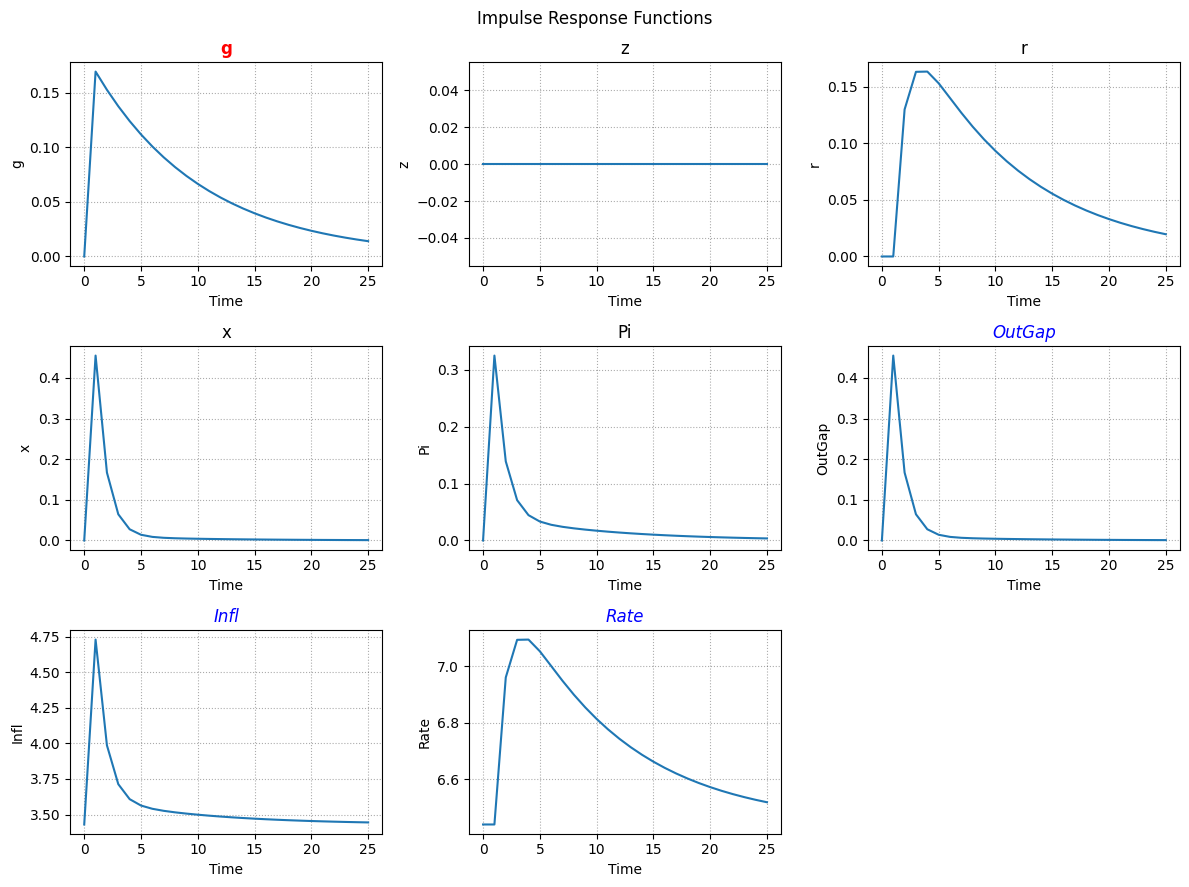

In [8]:
sol.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [32]:
sol.config.calibration.parameters

{beta: np.float64(0.9988224261043552),
 kappa: np.float64(0.4090888132984517),
 tau_inv: np.float64(0.8506806076295826),
 psi_pi: np.float64(3.4739614638478407),
 psi_x: np.float64(0.33794969288599447),
 rho_r: np.float64(0.7593286224469297),
 rho_g: np.float64(0.9013439777733883),
 rho_z: np.float64(0.8321895605263927),
 pi_star: np.float64(3.43),
 r_star: np.float64(3.01),
 sig_r: np.float64(0.11749745341778071),
 sig_g: np.float64(0.16961709744486583),
 sig_z: np.float64(0.5182100067121335),
 rho_gz: np.float64(0.3546966817474033),
 meas_infl: np.float64(1.0),
 meas_rate: np.float64(1.0),
 meas_outgap: np.float64(1.0),
 meas_rho_ir: np.float64(-0.32184530192396404),
 meas_rho_gi: np.float64(0.3066367252423019),
 meas_rho_gr: np.float64(-0.9858011129821717)}

In [9]:
kf = sol.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "linear",
    return_shocks=True,
)

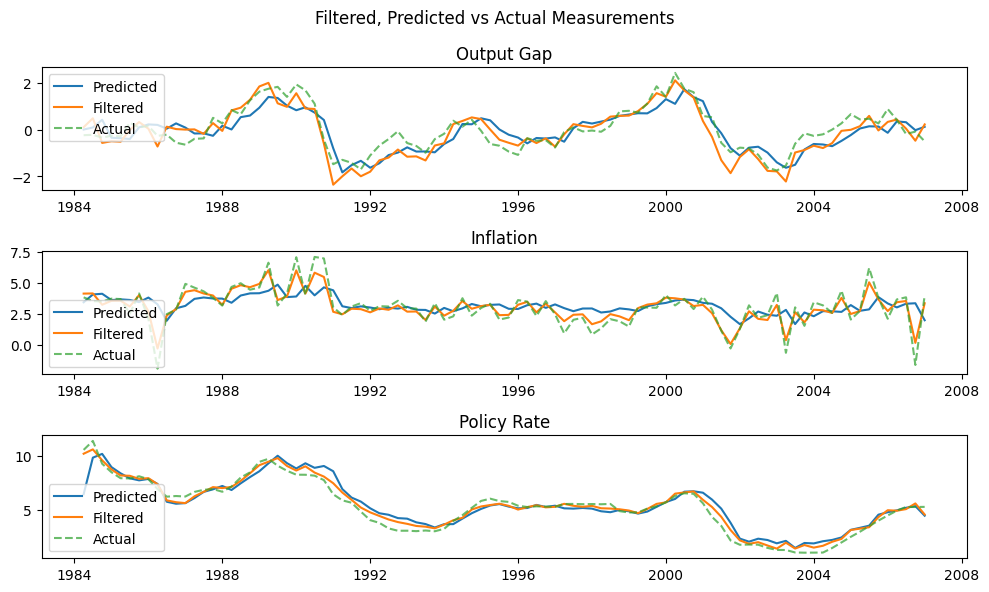

In [15]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Filtered, Predicted vs Actual Measurements")

ax[0].plot(idx, kf.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, kf.y_filt[:, 0], label="Filtered")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, kf.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, kf.y_filt[:, 1], label="Filtered")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, kf.y_pred[:, 2], label="Predicted")
ax[2].plot(idx, kf.y_filt[:, 2], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

In [16]:
gz = Shock(T=len(idx) - 1, dist="norm", multivar=True, seed=0).shock_generator()
r = Shock(T=len(idx) - 1, dist="norm", seed=1).shock_generator()
sim = sol.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)

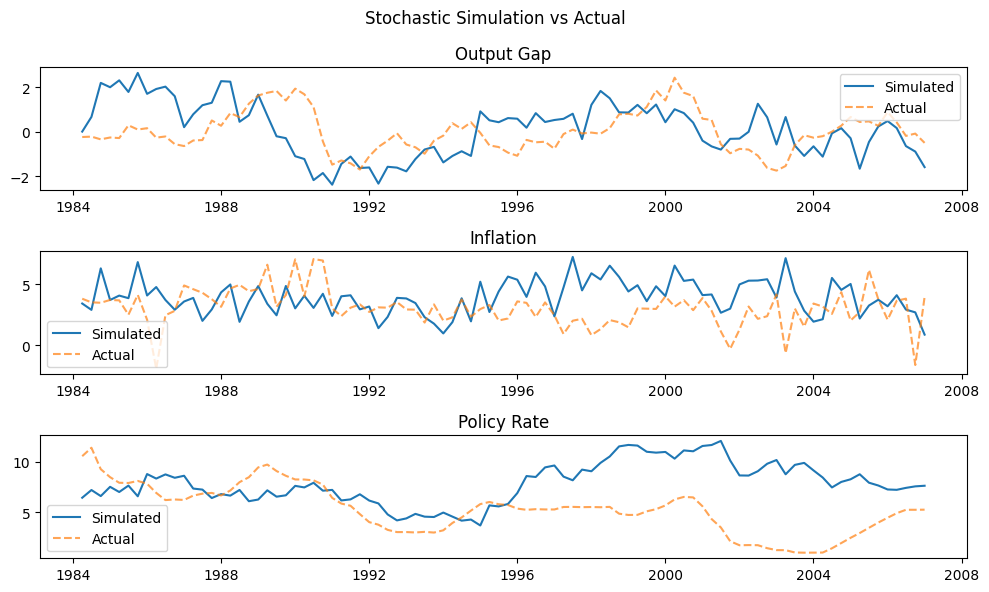

In [17]:
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Stochastic Simulation vs Actual")

ax[0].plot(idx, sim["OutGap"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, sim["Infl"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, sim["Rate"], label="Simulated")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

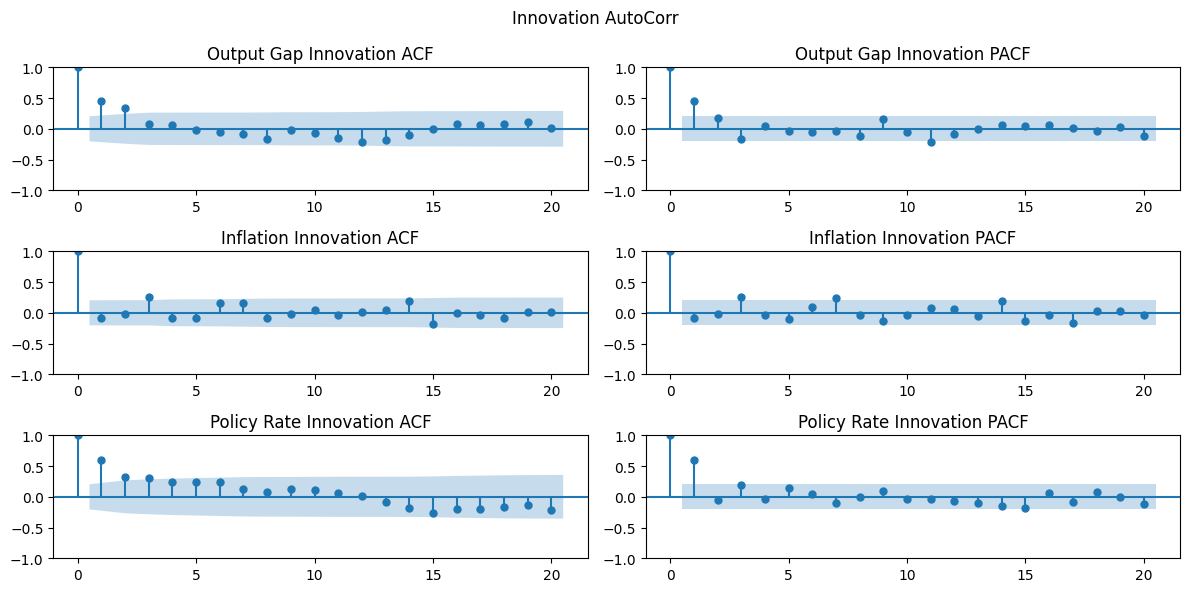

In [18]:
fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plt.suptitle("Innovation AutoCorr")
plot_acf(
    kf.innov[:, 0],
    ax=ax[0, 0],
    lags=20,
    title="Output Gap Innovation ACF",
)
plot_acf(
    kf.innov[:, 1],
    ax=ax[1, 0],
    lags=20,
    title="Inflation Innovation ACF",
)
plot_acf(
    kf.innov[:, 2],
    ax=ax[2, 0],
    lags=20,
    title="Policy Rate Innovation ACF",
)
plot_pacf(
    kf.innov[:, 0],
    ax=ax[0, 1],
    lags=20,
    title="Output Gap Innovation PACF",
)
plot_pacf(
    kf.innov[:, 1],
    ax=ax[1, 1],
    lags=20,
    title="Inflation Innovation PACF",
)
plot_pacf(
    kf.innov[:, 2],
    ax=ax[2, 1],
    lags=20,
    title="Policy Rate Innovation PACF",
)

plt.tight_layout()

In [19]:
template = TemplateConfig(
    include_expression=False,
    interaction_form="func",
    hessian_restriction="free",
    power_law_lower_bound=2,
    power_law_upper_bound=2,
    powers_in_interactions=False,
    constant_filtering="parametrize_all",
)

params = PySRParams(
    niterations=200,
    maxsize=12,
    complexity_of_constants=3,
    complexity_of_variables=1,
    deterministic=True,
    random_state=0,
    parallelism="serial",
)

res = sol.fit_kf(
    template_config=template,
    sr_params=params,
    y=observed.loc[observed.index >= "1984-01-01", :],
    variables=["r", "Pi", "x"],
    observable="Rate",
).expressions

/Users/guneykiymac/Desktop/Portfolio/SymbolicDSGE/.venv/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 2.530e+05
Progress: 2065 / 6200 total iterations (33.306%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.981e-01  0.000e+00  f_1 = #3
3           6.571e-01  3.027e-02  f_1 = -0.19412
5           5.920e-01  5.220e-02  f_1 = #2 * (#3 - #1)
7           5.724e-01  1.686e-02  f_1 = #2 * (0.28972 - #3)
9           5.379e-01  3.107e-02  f_1 = ((#2 * #2) - #2) * -0.28226
11          5.278e-01  9.406e-03  f_1 = (((#2 * #2) - #2) * -0.28226) - #3
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 2.390e+05
Progress: 4128

In [20]:
def sum_moments(series):
    out = pd.Series()

    out["mean"] = series.mean()
    out["var"] = series.var()
    out["Q1"] = series.quantile(0.25)
    out["Median"] = series.median()
    out["Q3"] = series.quantile(0.75)
    out["IQR"] = out["Q3"] - out["Q1"]
    return out.round(2)


sum_moments(pd.Series(kf.y_filt[:, 1]))

mean      3.06
var       1.32
Q1        2.48
Median    2.95
Q3        3.62
IQR       1.14
dtype: float64

In [30]:
def walk_round(x, n=3):
    for atom in preorder_traversal(x):
        if isinstance(atom, Float):
            x = x.subs(atom, round(atom, n))
    return x


res["initial_expr"] = res["initial_expr"].apply(lambda x: walk_round(x, n=3))
res[["initial_expr", "sympy_format", "loss", "complexity"]]

,initial_expr,sympy_format,loss,complexity
0,x,x,0.698132,1
1,-0.194,_C_1,0.657118,3
2,Pi*(-r + x),Pi*(_C_1*r + x),0.591974,5
3,Pi*(0.29 - x),Pi*(_C_1 + _C_2*x),0.572351,7
4,-0.282*Pi**2 + 0.282*Pi,_C_1*Pi + _C_2*Pi**_C_3,0.537873,9
5,-0.339*Pi**2 + 0.339*Pi - x,_C_1*x + _C_2*Pi + _C_3*Pi**_C_4,0.521432,11


In [31]:

# Augmented Model
conf_aug, kalman_aug = ModelParser(
    "../sdsge-papers/progress/report1/Augmented.yaml"
).get_all()
solver_aug = DSGESolver(conf_aug, kalman_aug)
comp_aug = solver_aug.compile(n_exog=3, n_state=3)

aug = solver_aug.solve(compiled=comp_aug)  # Solve without re-estimation

KeyError: OutGap

In [ ]:
aug.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [ ]:
kf_aug = aug.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "extended",
    return_shocks=True,
)

In [ ]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Augmented Model: Filtered, Predicted vs Actual Measurements")

ax[0].plot(idx, kf_aug.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, kf_aug.y_filt[:, 0], label="Filtered")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, kf_aug.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, kf_aug.y_filt[:, 1], label="Filtered")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, kf_aug.y_pred[:, 2], label="Predicted")
ax[2].plot(idx, kf_aug.y_filt[:, 2], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

In [ ]:
sim_aug = aug.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Augmented Model: Stochastic Simulation vs Actual")

ax[0].plot(idx, sim_aug["OutGap"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("OutGap")
ax[0].legend()

ax[1].plot(idx, sim_aug["Inflation"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, sim_aug["Rate"], label="Simulated")
ax[2].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plt.suptitle("Augmented Model: Innovation AutoCorr")

plot_acf(
    kf_aug.innov[:, 0],
    ax=ax[0, 0],
    lags=20,
    title="Output Gap Innovations ACF",
)
plot_acf(
    kf_aug.innov[:, 1],
    ax=ax[1, 0],
    lags=20,
    title="Inflation Innovations ACF",
)
plot_acf(
    kf_aug.innov[:, 2],
    ax=ax[2, 0],
    lags=20,
    title="Policy Rate Innovations ACF",
)
plot_pacf(
    kf_aug.innov[:, 0],
    ax=ax[0, 1],
    lags=20,
    title="Output Gap Innovations PACF",
)
plot_pacf(
    kf_aug.innov[:, 1],
    ax=ax[1, 1],
    lags=20,
    title="Inflation Innovations PACF",
)
plot_pacf(
    kf_aug.innov[:, 2],
    ax=ax[2, 1],
    lags=20,
    title="Policy Rate Innovations PACF",
)

plt.tight_layout()

In [ ]:

sum_moments(pd.Series(sim_aug["Infl"]))

In [ ]:
# Augmented + Re-estimated model

res_aug, sol_aug = solver_aug.estimate_and_solve(
    compiled=comp_aug,
    y=observed.loc[observed.index >= "1984-01-01", :],
    priors=prior_spec,
    method="mcmc",
    posterior_point="mean",
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    estimated_params=list(prior_spec.keys()),
    n_draws=1000,
    burn_in=500,
    thin=1,
)

In [ ]:
# Summarize results
param_names_aug = res_aug.param_names
post_mean_aug = np.mean(res_aug.samples, axis=0)
loglik_aug = np.mean(res_aug.logpost_trace)
accept_rate_aug = res_aug.accept_rate
pd.Series(
    {
        **dict(zip(param_names_aug, post_mean_aug)),
        "loglik": loglik_aug,
        "accept_rate": accept_rate_aug,
        "n_draws": res_aug.n_draws,
        "burn_in": res_aug.burn_in,
        "thin": res_aug.thin,
    }
)

In [ ]:
sol_aug.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [ ]:
kf_aug_reest = sol_aug.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "extended",
    return_shocks=True,
)

In [ ]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle(
    "Augmented + Re-estimated Model: Filtered, Predicted vs Actual Measurements"
)

ax[0].plot(idx, kf_aug_reest.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, kf_aug_reest.y_filt[:, 0], label="Filtered")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, kf_aug_reest.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, kf_aug_reest.y_filt[:, 1], label="Filtered")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, kf_aug_reest.y_pred[:, 2], label="Predicted")
ax[2].plot(idx, kf_aug_reest.y_filt[:, 2], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

In [ ]:
sim_aug_reest = sol_aug.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Augmented + Re-estimated Model: Stochastic Simulation vs Actual")

ax[0].plot(idx, sim_aug_reest["OutGap"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("OutGap")
ax[0].legend()

ax[1].plot(idx, sim_aug_reest["Infl"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, sim_aug_reest["Rate"], label="Simulated")
ax[2].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plt.suptitle("Augmented + Re-estimated Model: Innovation AutoCorr")
plot_acf(
    kf_aug_reest.innov[:, 0],
    ax=ax[0, 0],
    lags=20,
    title="Output Gap Innovations ACF",
)
plot_acf(
    kf_aug_reest.innov[:, 1],
    ax=ax[1, 0],
    lags=20,
    title="Inflation Innovationsc ACF",
)
plot_acf(
    kf_aug_reest.innov[:, 0],
    ax=ax[2, 0],
    lags=20,
    title="Policy Rate Innovations ACF",
)
plot_pacf(
    kf_aug_reest.innov[:, 0],
    ax=ax[0, 1],
    lags=20,
    title="Output Gap Innovations PACF",
)
plot_pacf(
    kf_aug_reest.innov[:, 1],
    ax=ax[1, 1],
    lags=20,
    title="Inflation Innovations PACF",
)
plot_pacf(
    kf_aug_reest.innov[:, 0],
    ax=ax[2, 1],
    lags=20,
    title="Policy Rate Innovations PACF",
)

plt.tight_layout()

In [ ]:
res_aug.hpd_intervals()